In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
np.random.seed(0)

In [12]:
data={
    "Patient_ID":np.arange(1,10001),
    "Age":np.random.randint(18,65,size=10000),
    "Gender":np.random.choice(["Male","Female"],size=10000),
    "Blood_pressure":np.random.randint(80,120,size=10000),
    "Sugar_level":np.random.randint(70,100,size=10000),
    "Cholesterol_level":np.random.randint(120,200,size=10000),
    "Heart_rate":np.random.randint(60,100,size=10000)
}

In [13]:
df=pd.DataFrame(data)

In [14]:
df

,Patient_ID,Age,Gender,Blood_pressure,Sugar_level,Cholesterol_level,Heart_rate
0,1,23,Female,95,72,136,73
1,2,50,Female,100,92,161,67
2,3,61,Female,98,86,194,78
3,4,57,Male,109,73,170,66
4,5,49,Male,104,79,133,84
...,...,...,...,...,...,...,...
9995,9996,54,Male,104,76,157,81
9996,9997,24,Female,111,87,166,85
9997,9998,53,Male,87,83,176,63
9998,9999,45,Male,95,86,183,77


In [15]:
pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.8 MB/s eta 0:00:00


In [17]:

from faker import Faker
fake=Faker()
df["name"]=[fake.name() for _ in range(10000)]
df

,Patient_ID,Age,Gender,Blood_pressure,Sugar_level,Cholesterol_level,Heart_rate,name
0,1,23,Female,95,72,136,73,Allison Reyes
1,2,50,Female,100,92,161,67,Bernard Bryan
2,3,61,Female,98,86,194,78,Theresa Mack
3,4,57,Male,109,73,170,66,Tina Chan
4,5,49,Male,104,79,133,84,Stephen Stevens
...,...,...,...,...,...,...,...,...
9995,9996,54,Male,104,76,157,81,Carolyn Roberts
9996,9997,24,Female,111,87,166,85,Jonathan Ruiz
9997,9998,53,Male,87,83,176,63,Brian Clark
9998,9999,45,Male,95,86,183,77,Elizabeth Sherman


# Data cleaning

In [18]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Patient_ID           0
Age                  0
Gender               0
Blood_pressure       0
Sugar_level          0
Cholesterol_level    0
Heart_rate           0
name                 0
dtype: int64


# Fill missing values with mean

In [20]:
df["Sugar_level"].fillna(df["Sugar_level"].mean(), inplace=True)

/tmp/ipykernel_28171/3684208392.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Sugar_level"].fillna(df["Sugar_level"].mean(), inplace=True)


# Descriptive Statistics

In [21]:
print("\nStatistical Summary:\n", df.describe())


Statistical Summary:
         Patient_ID          Age  Blood_pressure   Sugar_level  \
count  10000.00000  10000.00000    10000.000000  10000.000000   
mean    5000.50000     41.02620       99.359000     84.515900   
std     2886.89568     13.59658       11.519409      8.653429   
min        1.00000     18.00000       80.000000     70.000000   
25%     2500.75000     29.00000       89.000000     77.000000   
50%     5000.50000     41.00000       99.000000     85.000000   
75%     7500.25000     53.00000      109.000000     92.000000   
max    10000.00000     64.00000      119.000000     99.000000   

       Cholesterol_level    Heart_rate  
count       10000.000000  10000.000000  
mean          159.388900     79.615700  
std            23.130364     11.515454  
min           120.000000     60.000000  
25%           139.000000     70.000000  
50%           159.000000     80.000000  
75%           180.000000     90.000000  
max           199.000000     99.000000  


# Risk Classification

In [23]:
def classify_risk(row):
    if (row["Blood_pressure"] > 140 or
        row["Sugar_level"] > 180 or
        row["Cholesterol_level"] > 240):
        return "High"
    elif (row["Blood_pressure"] > 120 or
          row["Sugar_level"] > 140 or
          row["Cholesterol_level"] > 200):
        return "Medium"
    else:
        return "Low"
df["Risk_Level"] = df.apply(classify_risk, axis=1)

# Group-Based Analysis

In [25]:
df["Age_Group"] = pd.cut(df["Age"], bins=[18, 30, 50, 80], labels=["Young", "Middle", "Old"])
gender_group = df.groupby("Gender")["Blood_pressure"].mean()
print("\nGender-wise BP:\n", gender_group)
risk_count = df["Risk_Level"].value_counts()
print("\nRisk Distribution:\n", risk_count)


Gender-wise BP:
 Gender
Female    99.294363
Male      99.424627
Name: Blood_pressure, dtype: float64

Risk Distribution:
 Risk_Level
Low    10000
Name: count, dtype: int64


# Relationship Analysis

In [26]:
correlation = df.corr(numeric_only=True)
print("\nCorrelation Matrix:\n", correlation)


Correlation Matrix:
                    Patient_ID       Age  Blood_pressure  Sugar_level  \
Patient_ID           1.000000  0.005619       -0.020634    -0.013453   
Age                  0.005619  1.000000        0.020734    -0.004848   
Blood_pressure      -0.020634  0.020734        1.000000    -0.009951   
Sugar_level         -0.013453 -0.004848       -0.009951     1.000000   
Cholesterol_level   -0.016031  0.008411        0.012523     0.006116   
Heart_rate          -0.026855 -0.001015       -0.010993     0.018918   

                   Cholesterol_level  Heart_rate  
Patient_ID                 -0.016031   -0.026855  
Age                         0.008411   -0.001015  
Blood_pressure              0.012523   -0.010993  
Sugar_level                 0.006116    0.018918  
Cholesterol_level           1.000000    0.005727  
Heart_rate                  0.005727    1.000000  


# Bar chart

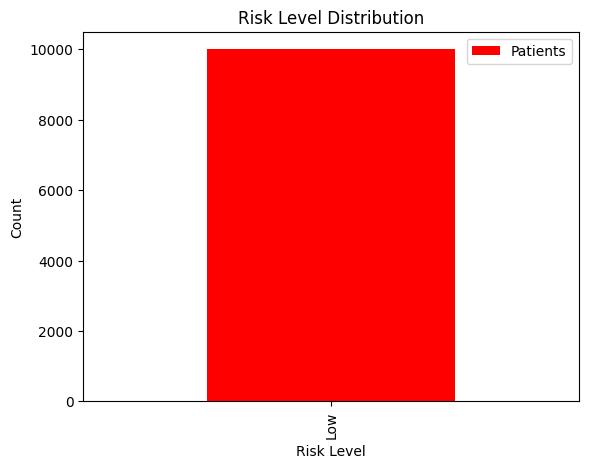

In [30]:
risk_count.plot(
                kind='bar',
                color=['red', 'green', 'blue']
)
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.legend(["Patients"])
plt.show()

# Pie chart

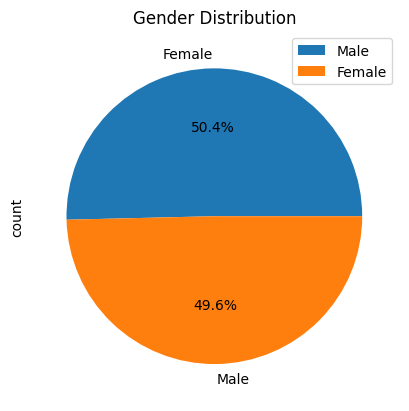

In [31]:
df["Gender"].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    color=['pink','blue'])
plt.title("Gender Distribution")
plt.legend(["Male", "Female"])
plt.show()

# Histogram

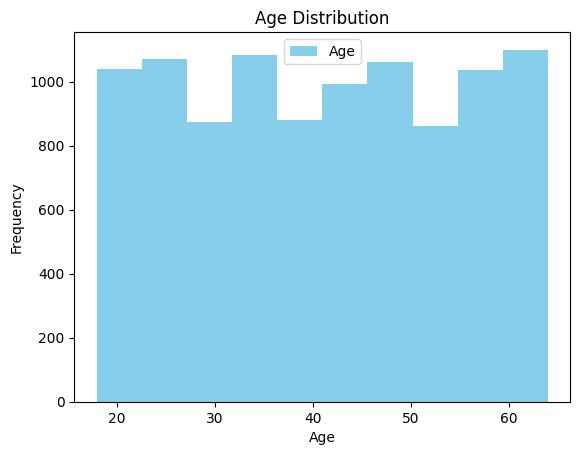

In [34]:
plt.hist(df["Age"],
         color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend(["Age"])
plt.show()

# Scatter plot

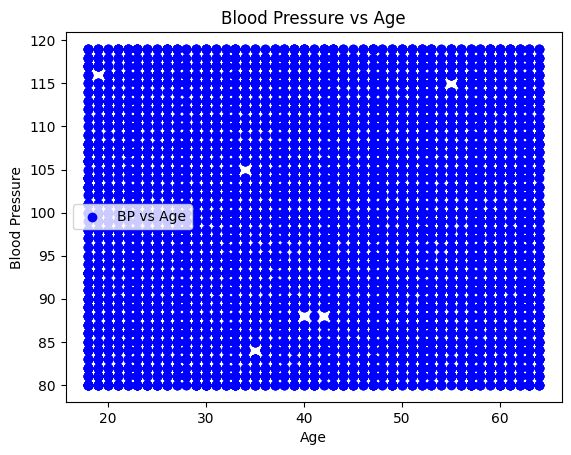

In [41]:
plt.scatter(df["Age"],
            df["Blood_pressure"],
            color=['blue'])
plt.title("Blood Pressure vs Age")
plt.xlabel("Age")
plt.ylabel("Blood Pressure")
plt.legend(["BP vs Age"])
plt.show()

# Box plot

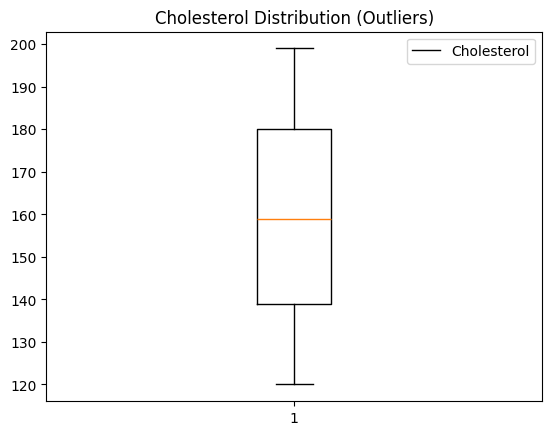

In [45]:
plt.boxplot(df["Cholesterol_level"])
plt.title("Cholesterol Distribution (Outliers)")
plt.legend(["Cholesterol"])
plt.show()

# Heat map

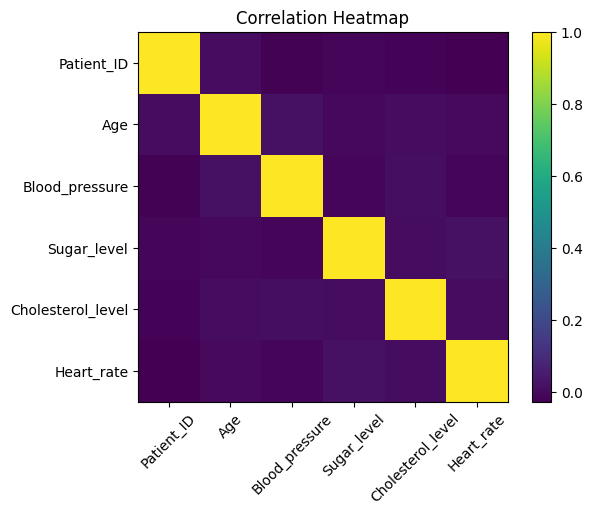

In [46]:
plt.imshow(correlation)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.show()

# Identify High Risk Patients

In [47]:
high_risk = df[df["Risk_Level"] == "High"]
print("\nHigh Risk Patients:\n", high_risk.head())


High Risk Patients:
 Empty DataFrame
Columns: [Patient_ID, Age, Gender, Blood_pressure, Sugar_level, Cholesterol_level, Heart_rate, name, Risk_Level, Age_Group]
Index: []


# Insights

In [49]:
print("\nInsights:")
print("- Most patients fall under:", risk_count.idxmax())
print("- Average BP:", df["Blood_pressure"].mean())
print("- Correlation between Age & BP:", correlation.loc["Age", "Blood_pressure"])


Insights:
- Most patients fall under: Low
- Average BP: 99.359
- Correlation between Age & BP: 0.020733776656065836
